<a href="https://colab.research.google.com/github/PaulinaG27/Ciencia-Datos/blob/main/sesiones_practicas%20/sp_1_Julian_Isaza_Marin_Paulina_Garcia_Aristizabal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:Blue;"><strong>Preparación de la fuente de datos y librerías</strong></span>

In [2]:
#Se importan las librerías necesarias (basándonos en los ejemplos del archivo ciclo de vida del repositorio del curso)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#Se descarga el dataset desde Kaggle
import kagglehub

house_rent_path = kagglehub.dataset_download('iamsouravbanerjee/house-rent-prediction-dataset')

print('Data source import complete.')

#Se crea la carpeta destino de la base de datos llamada data
origen = house_rent_path
carpeta_destino = 'data'
os.makedirs(carpeta_destino, exist_ok=True)

#Se copia el archivo .csv
archivo = 'House_Rent_Dataset.csv'

origen_archivo = os.path.join(origen, archivo)
destino_archivo = os.path.join(carpeta_destino, archivo)

shutil.copy(origen_archivo, destino_archivo)

print(f"{archivo} copiado a {carpeta_destino}/")
print("Archivo copiado con éxito.")


#Se carga el archivo csv con respectivas columnas (12 en total)
df = pd.read_csv('data/House_Rent_Dataset.csv')

print("Dataset cargado correctamente.")
print(df.head())

Using Colab cache for faster access to the 'house-rent-prediction-dataset' dataset.
Data source import complete.
House_Rent_Dataset.csv copiado a data/
Archivo copiado con éxito.
Dataset cargado correctamente.
    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South

## <span style="color:Blue;"><strong>1. Introducción</strong></span>

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>1. Breve presentación del problema o pregunta de investigación.</b>  
</div>

¿Qué características del inmueble y de su ubicación influyen en la determinación del precio de renta?
<br>
<br>
<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b> 2. Contexto: ¿Por qué es relevante este problema? </b>  
</div>

La problemática surge a partir de una discusión con ciertas situaciones que han afectado a Medellín durante los últimos años, debido a la gentrificación y las altas tasas de arrendamiento en la ciudad. Lo cual ha generado un impacto económico directo tanto para los arrendatarios como para el mercado inmobiliario, afectando diferentes aspectos de la cotidianidad de la población. A pesar de que no estamos utilizando un dataset que cuente con características propias de la problemática en la ciudad de Medellín, mediante esta base de datos buscamos entender cómo se determinan los precios de renta según la ubicación y las características del inmueble, así como también analizar qué tan justos pueden ser los arrendamientos en otras ciudades (en este caso, las pertenecientes a la India) para en un futuro abordar esta problemática de manera local con una base más sólida. <br><br>


<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b> 3. Relación entre el problema y la base de datos seleccionada. </b>  
</div>

Para abordar la pregunta de investigación, utilizamos el conjunto de datos House Rent Prediction Dataset disponible en la plataforma Kaggle. Este dataset recopila información sobre propiedades en diferentes ciudades de la India e incluye variables relacionadas con el precio de renta (`Rent`), características físicas del inmueble como tamaño (`Size`), número de habitaciones (`BHK`) y baños (`Bathroom`), así como variables de ubicación (`City, Area_Locality`) y condiciones del inmueble (`Furnishing_Status`, `Floor`).

Gracias a esta diversidad de atributos, es posible analizar cómo influyen tanto las características estructurales como la ubicación en la determinación del precio de renta. Aunque el dataset no corresponde a la ciudad de Medellín, permite estudiar el comportamiento del mercado inmobiliario en otro contexto urbano y comprender qué factores suelen tener mayor impacto en el valor de arrendamiento.

## <span style="color:Blue;"><strong>2. Descripción de la base de datos</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Número de registros y variables.</b><br>
<b>- Breve descripción de las variables más importantes.</b><br>
<b>- Tipos de datos (numéricas, categóricas, fechas, texto, etc.).</b>
</div>

In [3]:
# Visualizar una pequeña muestra de los datos
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 4746
Número de variables: 12


In [5]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
object    8
int64     4
Name: count, dtype: int64


In [6]:
# Clasificación de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))


🔹 Variables categóricas:
- Posted On
- Floor
- Area Type
- Area Locality
- City
- Furnishing Status
- Tenant Preferred
- Point of Contact

🔸 Variables numéricas:
- BHK
- Rent
- Size
- Bathroom


<br>
<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>Breve descripción de las variables más importantes:</b>  
</div>

<br>

| Variable | Tipo | Descripción |
|----------|------|------------|
| **BHK** | Numérica | Número de habitaciones. |
| **Rent** | Numérica | Valor mensual del arriendo. |
| **Size** | Numérica | Área total de la propiedad en pies cuadrados (sqft). |
| **Floor** | Categórica | Piso o nivel en el que se encuentra la vivienda. |
| **Area Locality** | Categórica | Nombre del vecindario o zona. |
| **City** | Categórica | Ciudad donde se ubica la propiedad. |
| **Furnishing Status** | Categórica | Nivel de amueblamiento (Unfurnished, Semi-Furnished, Furnished). |
<br>

In [7]:
# Descripción estadística general
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967.490729     1.965866
std       0.832256  7.810641e+04   634.202328     0.884532
min       1.000000  1.200000e+03    10.000000     1.000000
25%       2.000000  1.000000e+04   550.000000     1.000000
50%       2.000000  1.600000e+04   850.000000     2.000000
75%       3.000000  3.300000e+04  1200.000000     2.000000
max       6.000000  3.500000e+06  8000.000000    10.000000


## <span style="color:Blue;"><strong>3. Análisis inicial de las variables</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Identificación de las variables clave.</b><br>
<b>- Conteo de valores, tipos de datos y valores faltantes.</b><br>
</div>

In [8]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)


In [9]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
Area Locality        2235
Size                  615
Floor                 480
Rent                  243
Posted On              81
Bathroom                8
BHK                     6
City                    6
Area Type               3
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64



<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;">
<b>Pregunta de investigación: ¿Qué características del inmueble y de su ubicación influyen en la determinación del precio de renta?</b>  
</div>



In [10]:
# Variables más importantes
variables_clave = ['Rent', 'Size', 'City', 'Area Locality', 'BHK', 'Furnishing Status', 'Floor']
print("\nVista rápida de variables clave:")
print(df[variables_clave].head())
# Vista rápida de las variables clave
print("\nEstadísticas descriptivas de variables clave:")
print(df[variables_clave].describe())


Vista rápida de variables clave:
    Rent  Size     City             Area Locality  BHK Furnishing Status  \
0  10000  1100  Kolkata                    Bandel    2       Unfurnished   
1  20000   800  Kolkata  Phool Bagan, Kankurgachi    2    Semi-Furnished   
2  17000  1000  Kolkata   Salt Lake City Sector 2    2    Semi-Furnished   
3  10000   800  Kolkata               Dumdum Park    2       Unfurnished   
4   7500   850  Kolkata             South Dum Dum    2       Unfurnished   

             Floor  
0  Ground out of 2  
1       1 out of 3  
2       1 out of 3  
3       1 out of 2  
4       1 out of 2  

Estadísticas descriptivas de variables clave:
               Rent         Size          BHK
count  4.746000e+03  4746.000000  4746.000000
mean   3.499345e+04   967.490729     2.083860
std    7.810641e+04   634.202328     0.832256
min    1.200000e+03    10.000000     1.000000
25%    1.000000e+04   550.000000     2.000000
50%    1.600000e+04   850.000000     2.000000
75%    3.30000

## <span style="color:Blue;"><strong>4. Visualizaciones exploratorias básicas</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Gráficos de dispersión para relaciones entre variables.</b><br>
<b>- Breve interpretación de lo que muestran las gráficas.</b><br>
<b>- Histogramas o gráficos de barras para variables numéricas y categóricas.</b><br>
</div>


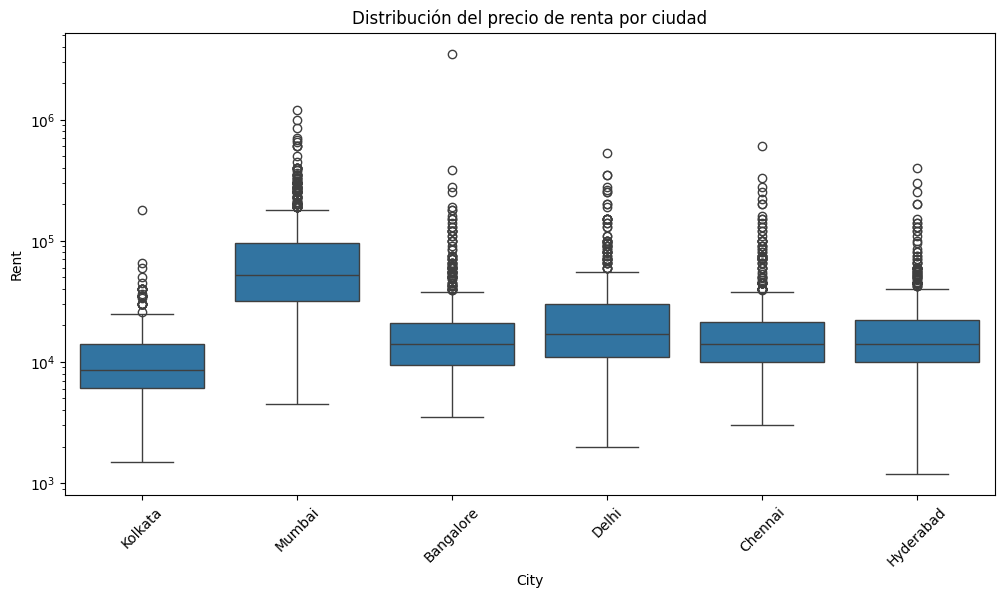

In [11]:
# Boxplot: Renta en ciudades
plt.figure(figsize=(12,6))
sns.boxplot(x='City', y='Rent', data=df)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Distribución del precio de renta por ciudad")
plt.show()

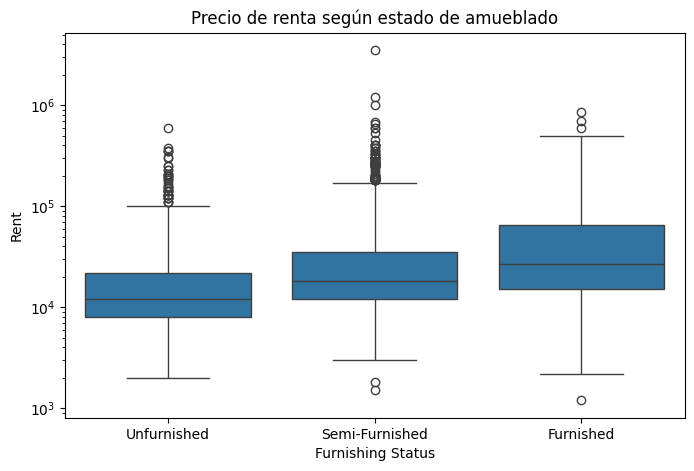

In [12]:
#Boxplot: Precio de renta segun el amueblado
plt.figure(figsize=(8,5))
plt.yscale('log')
sns.boxplot(x='Furnishing Status', y='Rent', data=df)
plt.title("Precio de renta según estado de amueblado")
plt.show()

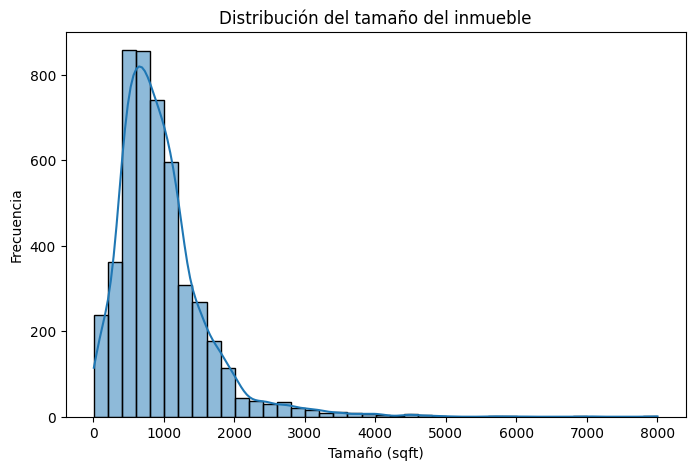

In [13]:
#Histograma: Distribución del tamaño del inmueble
plt.figure(figsize=(8,5))
sns.histplot(df['Size'], bins=40, kde=True)
plt.title("Distribución del tamaño del inmueble")
plt.xlabel("Tamaño (sqft)")
plt.ylabel("Frecuencia")
plt.show()

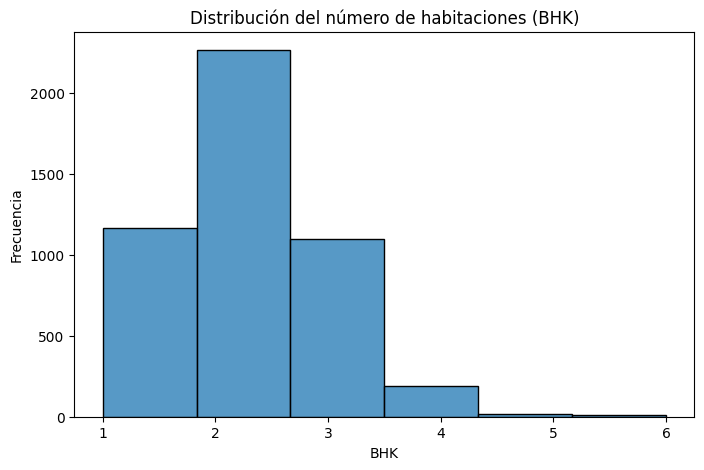

In [14]:
# Histograma: BHK
plt.figure(figsize=(8,5))
sns.histplot(df['BHK'], bins=df['BHK'].nunique(), kde=False)
plt.title("Distribución del número de habitaciones (BHK)")
plt.xlabel("BHK")
plt.ylabel("Frecuencia")
plt.show()

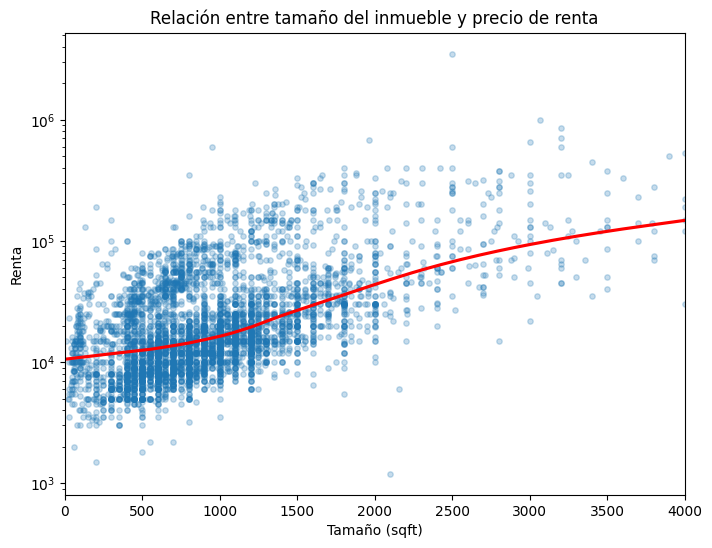

In [21]:
#regplot: Relación tamaño-precio
plt.figure(figsize=(8,6))
sns.regplot(x='Size', y='Rent', data=df,lowess=True, scatter_kws={'alpha':0.25, 's':15}, line_kws={'color':'red'})
plt.yscale('log')
plt.xlim(0,4000)
plt.title("Relación entre tamaño del inmueble y precio de renta")
plt.xlabel("Tamaño (sqft)")
plt.ylabel("Renta")
plt.show()

## <span style="color:Blue;"><strong>5. Interpretaciones iniciales</strong></span>

<div style="background-color:#E6F4FF; padding:10px; border-radius:8px;"><br>
<b>¿Qué tendencias o patrones básicos se observan?</b>  <br>

<b>Distribución del precio de renta por ciudad</b>  
<ul>
  <li>Mumbai presenta claramente las rentas más altas ya que tiene la mediana superior al resto</li>
  <li>Delhi, Bangalore, Chennai y Hyderabad tienen medianas intermedias y bastante similares entre sí.</li>
  <li>Kolkata muestra las rentas más bajas en comparación.</li>
  <li>Se observan algunos valores atípicos en ausencias (absences).</li>
  <li>Hay muchos valores atípicos en todas las ciudades, especialmente en Mumbai y Bangalore.</li>
</ul>

<b>Precio según estado de amueblado</b>
<ul>
  <li>Las viviendas Furnished tienen la mediana más alta.</li>
  <li>Las Semi-Furnished ocupan un punto intermedio.</li>
  <li>Las Unfurnished presentan las rentas más bajas.</li>
  <li>También existen outliers importantes en las tres categorías.</li>
  <li>Se puede determinar que existe una relación positiva entre el nivel de amueblado y el precio de renta</li>
</ul>

<b>Distribución del tamaño del inmueble</b>
<ul>
  <li>La mayoría de propiedades se concentran entre 500 y 1500 sqft.</li>
  <li>La distribución es fuertemente asimétrica a la derecha.</li>
  <li>Existen propiedades muy grandes pero son pocas</li>
</ul>

<b>Distribución del número de habitaciones (BHK)</b>
<ul>
  <li>La mayoría de propiedades son de 2 BHK.</li>
  <li>Luego siguen 1 BHK y 3 BHK.</li>
  <li>Muy pocas propiedades tienen 4 o más habitaciones.</li>
</ul>

<b>Relación entre tamaño del inmueble y precio de renta</b>
<ul>
  <li>En general, mientras más grande es el tamaño del inmueble, el precio de renta es mayor.</li>
  <li>Para un mismo tamaño hay diferencias en el precio, esto nos puede decir que además del tamaño, influyen otros factores.</li>
  <li>Hay casos aislados de inmuebles que presentan precios de renta muy altos a comparación de los demás.</li>
  <li>La línea de tendencia muestra un crecimiento no perfectamente lineal, sino suavemente curvo.</li>
  <li>La mayoría de los datos se concentran entre 400 y 1500 sqft.</li>
</ul>

</div>

<br>

<div style="background-color:#E8F5E9; padding:10px; border-radius:8px;">
<b>¿Qué limitaciones tiene la base de datos?</b>  
<ul>
  <li>Existen muchos valores atípicos, lo que puede afectar promedios.</li>
  <li>No se observa normalidad en la distribución de Rent.</li>
  <li>No se controla por ubicación exacta dentro de la ciudad (zona premium vs zona económica).</li>
  <li>No se está considerando aún el precio por sqft, que sería una métrica más justa.</li>
</ul>
</div>

<br>

<div style="background-color:#FFF9C4; padding:10px; border-radius:8px;">
<b>El precio de renta aumenta significativamente en Mumbai respecto a otras ciudades.</b>  
<ul>
  <li>El estado de amueblado influye positivamente en el precio (el precio de amueblado está balanceado con el precio final)</li>
  <li>El tamaño del inmueble, en su mayoróa, tiene correlación positiva con la renta.</li>
  <li>Los estudiantes con más ausencias tienden a obtener peores resultados académicos.</li>
  <li>El precio por sqft podría variar considerablemente entre ciudades.</li>
</ul>
</div>


## <span style="color:Blue;"><strong>6. Conclusiones</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Resumen de los principales hallazgos iniciales.</b><br>
<b>- Reflexión sobre cómo este entregable contribuye al desarrollo del proyecto completo.</b><br>
</div>


- La ciudad influye significativamente en el precio de renta.
- El estado de amueblado impacta directamente el precio.
- El mercado se concentra en propiedades medianas.
- Existe una relación positiva entre tamaño y renta.

<b>- De acuerdo a lo desarrollado, este entregable permitió: </b>

- Comprender la estructura y comportamiento general del mercado inmobiliario del dataset así como el adecuado manejo del mismo.

- También se pudo Identificar variables clave que influyen en el precio (City, Size, BHK, Furnishing Status) que son fundamentales para nuestro caso de estudio o problematica así como la formulación de hipótesis claras para el mismo.


## <span style="color:Blue;"><strong>7. Referencias</strong></span>

<div style="background-color:#FCE4EC; padding:10px; border-radius:8px;">
<b>- Fuente(s) de los datos.</b><br>
<b>- Cualquier referencia bibliográfica o técnica utilizada.</b><br>
</div>

### **Fuente de los datos**
- Dataset: **House Rent Prediction Dataset**
  **Fuente:** [Kaggle](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset/data?select=House_Rent_Dataset.csv).  
  **Autores:** Sourav Banerjee.  
  **Descripción:** Datos sobre casas en renta así como su ubicación, fecha de publicación, características y precio.

---

<div style="text-align:center; color:#607D8B; font-weight:bold; font-size:14px;">
“Sin datos, solo eres otra persona con una opinión.” – W. Edwards Deming
</div>